# Semana 12: Aprendizaje Semi-supervisado - Pseudo-labeling

**Integrante:** Thalia Gonzalez  
**Tema:** Impacto ambiental de la energia  
**Fuente:** Dataset energetico clasificado con K-Means en Semana 10

El objetivo es usar los clusters obtenidos sin etiquetas previas como pseudo-etiquetas y evaluar cuanto logran aprender distintos modelos supervisados.


## 1. Librerias y sesion Spark

El flujo utiliza PySpark para entrenar los modelos y scikit-learn unicamente para visualizar el arbol.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession, functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml.classification import (
    DecisionTreeClassifier, RandomForestClassifier, LinearSVC,
    LogisticRegression, OneVsRest
)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, RegressionEvaluator
from pyspark.ml.regression import LinearRegression

from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier as SklearnDecisionTree

sns.set_theme(style="whitegrid")
spark = SparkSession.builder.appName("Semana12_PseudoLabeling_Energia_Thalia").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")


## 2. Carga de datos pseudo-etiquetados

La columna `prediction` corresponde al cluster asignado en Semana 10. Para ejecutar esta celda, primero se debe ejecutar el notebook de Semana 10, que genera la carpeta Parquet y guarda el modelo K-Means.


In [2]:
RUTA_DATOS = "/home/jovyan/work/semanas/Semana 10 Aprendizaje No Supervisado/modelos/datos_etiquetados_kmeans"
df_clusters = spark.read.parquet(RUTA_DATOS)

print("Registros pseudo-etiquetados:", df_clusters.count())
print("Columnas disponibles:", df_clusters.columns)
df_clusters.select("item", "tecnologia", "categoria_energia", "capacidad_mw", "prediction").show(10, truncate=False)
df_clusters.groupBy("prediction").count().orderBy("prediction").show()


Registros pseudo-etiquetados: 500
Columnas disponibles: ['item', 'pais', 'tecnologia', 'categoria_energia', 'capacidad_mw', 'frecuencia_tecnologia', 'es_renovable', 'features', 'scaledFeatures', 'pcaFeatures', 'prediction']
+-----------------------------------------------------------------+----------+-----------------+------------+----------+
|item                                                             |tecnologia|categoria_energia|capacidad_mw|prediction|
+-----------------------------------------------------------------+----------+-----------------+------------+----------+
|Kajaki Hydroelectric Power Plant Afghanistan - Hydro             |Hydro     |Renovable        |33.0        |0         |
|Kandahar DOG - Solar                                             |Solar     |Renovable        |10.0        |0         |
|Kandahar JOL - Solar                                             |Solar     |Renovable        |10.0        |0         |
|Mahipar Hydroelectric Power Plant Afghanistan - H

## 3. Preparacion para clasificacion supervisada

Spark espera que la variable que se desea predecir se llame `label`. En este caso, la etiqueta no fue entregada originalmente: fue creada por K-Means y por eso se considera pseudo-labeling.


In [3]:
df_supervisado = (df_clusters
    .withColumnRenamed("prediction", "label")
    .withColumn("label", F.col("label").cast("double"))
)

train_data, test_data = df_supervisado.randomSplit([0.7, 0.3], seed=42)
print("Datos de entrenamiento:", train_data.count())
print("Datos de prueba:", test_data.count())


Datos de entrenamiento: 374
Datos de prueba: 126


## 4. Arbol de Decision

El arbol intenta reproducir la segmentacion construida por K-Means usando las variables escaladas de capacidad, frecuencia de tecnologia y clasificacion renovable/fosil.


In [4]:
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy"
)

dt = DecisionTreeClassifier(featuresCol="scaledFeatures", labelCol="label", maxDepth=5, seed=42)
dt_model = dt.fit(train_data)
predictions_dt = dt_model.transform(test_data)
accuracy_dt = evaluator.evaluate(predictions_dt)

print(f"Accuracy del Arbol de Decision: {accuracy_dt * 100:.2f}%")
predictions_dt.select("item", "tecnologia", "label", "prediction", "probability").show(10, truncate=False)


Accuracy del Arbol de Decision: 99.21%
+-----------------------+----------+-----+----------+-------------+
|item                   |tecnologia|label|prediction|probability  |
+-----------------------+----------+-----+----------+-------------+
|AGUA DEL TORO - Hydro  |Hydro     |0.0  |0.0       |[1.0,0.0,0.0]|
|ALUMINE - Oil          |Oil       |2.0  |2.0       |[0.0,0.0,1.0]|
|ARROYITO - Hydro       |Hydro     |0.0  |0.0       |[1.0,0.0,0.0]|
|ATUCHA I - Nuclear     |Nuclear   |0.0  |0.0       |[1.0,0.0,0.0]|
|Ain Azel - Solar       |Solar     |0.0  |0.0       |[1.0,0.0,0.0]|
|Ain Djasser - Gas      |Gas       |2.0  |2.0       |[0.0,0.0,1.0]|
|Ain Sekhouna - Solar   |Solar     |0.0  |0.0       |[1.0,0.0,0.0]|
|Albany Wind Farm - Wind|Wind      |0.0  |0.0       |[1.0,0.0,0.0]|
|Amcor Gawler - Oil     |Oil       |2.0  |2.0       |[0.0,0.0,1.0]|
|Anglesea - Coal        |Coal      |0.0  |0.0       |[1.0,0.0,0.0]|
+-----------------------+----------+-----+----------+-------------+
only show

### Matriz de confusion del Arbol de Decision


+-----+---+---+---+
|label|0.0|1.0|2.0|
+-----+---+---+---+
|  0.0| 58|  0|  0|
|  1.0|  1| 11|  0|
|  2.0|  0|  0| 56|
+-----+---+---+---+



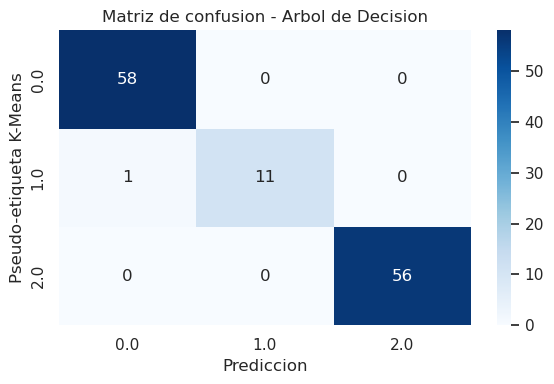

In [5]:
matriz_dt = (predictions_dt.groupBy("label").pivot("prediction").count().fillna(0).orderBy("label"))
matriz_dt.show()

pdf_matriz = matriz_dt.toPandas().set_index("label")
plt.figure(figsize=(6, 4))
sns.heatmap(pdf_matriz, annot=True, fmt="g", cmap="Blues")
plt.title("Matriz de confusion - Arbol de Decision")
plt.xlabel("Prediccion")
plt.ylabel("Pseudo-etiqueta K-Means")
plt.tight_layout()
plt.show()


### Reglas aprendidas por Spark


In [6]:
print("=== ESTRUCTURA LOGICA DEL ARBOL ===")
print(dt_model.toDebugString)


=== ESTRUCTURA LOGICA DEL ARBOL ===
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_c75fea4105af, depth=4, numNodes=15, numClasses=3, numFeatures=3
  If (feature 1 <= 0.2693698102125645)
   If (feature 0 <= 1.4999523891983788)
    If (feature 0 <= 1.1310794915234563)
     Predict: 0.0
    Else (feature 0 > 1.1310794915234563)
     If (feature 1 <= -1.6838976380249095)
      Predict: 1.0
     Else (feature 1 > -1.6838976380249095)
      Predict: 0.0
   Else (feature 0 > 1.4999523891983788)
    If (feature 0 <= 2.3404338593552074)
     If (feature 1 <= -1.6838976380249095)
      Predict: 1.0
     Else (feature 1 > -1.6838976380249095)
      Predict: 0.0
    Else (feature 0 > 2.3404338593552074)
     Predict: 1.0
  Else (feature 1 > 0.2693698102125645)
   If (feature 0 <= 1.4999523891983788)
    Predict: 2.0
   Else (feature 0 > 1.4999523891983788)
    Predict: 1.0



### Visualizacion didactica del arbol

Para representar el arbol graficamente se entrena una copia pequena con scikit-learn a partir de las mismas variables originales y las pseudo-etiquetas.


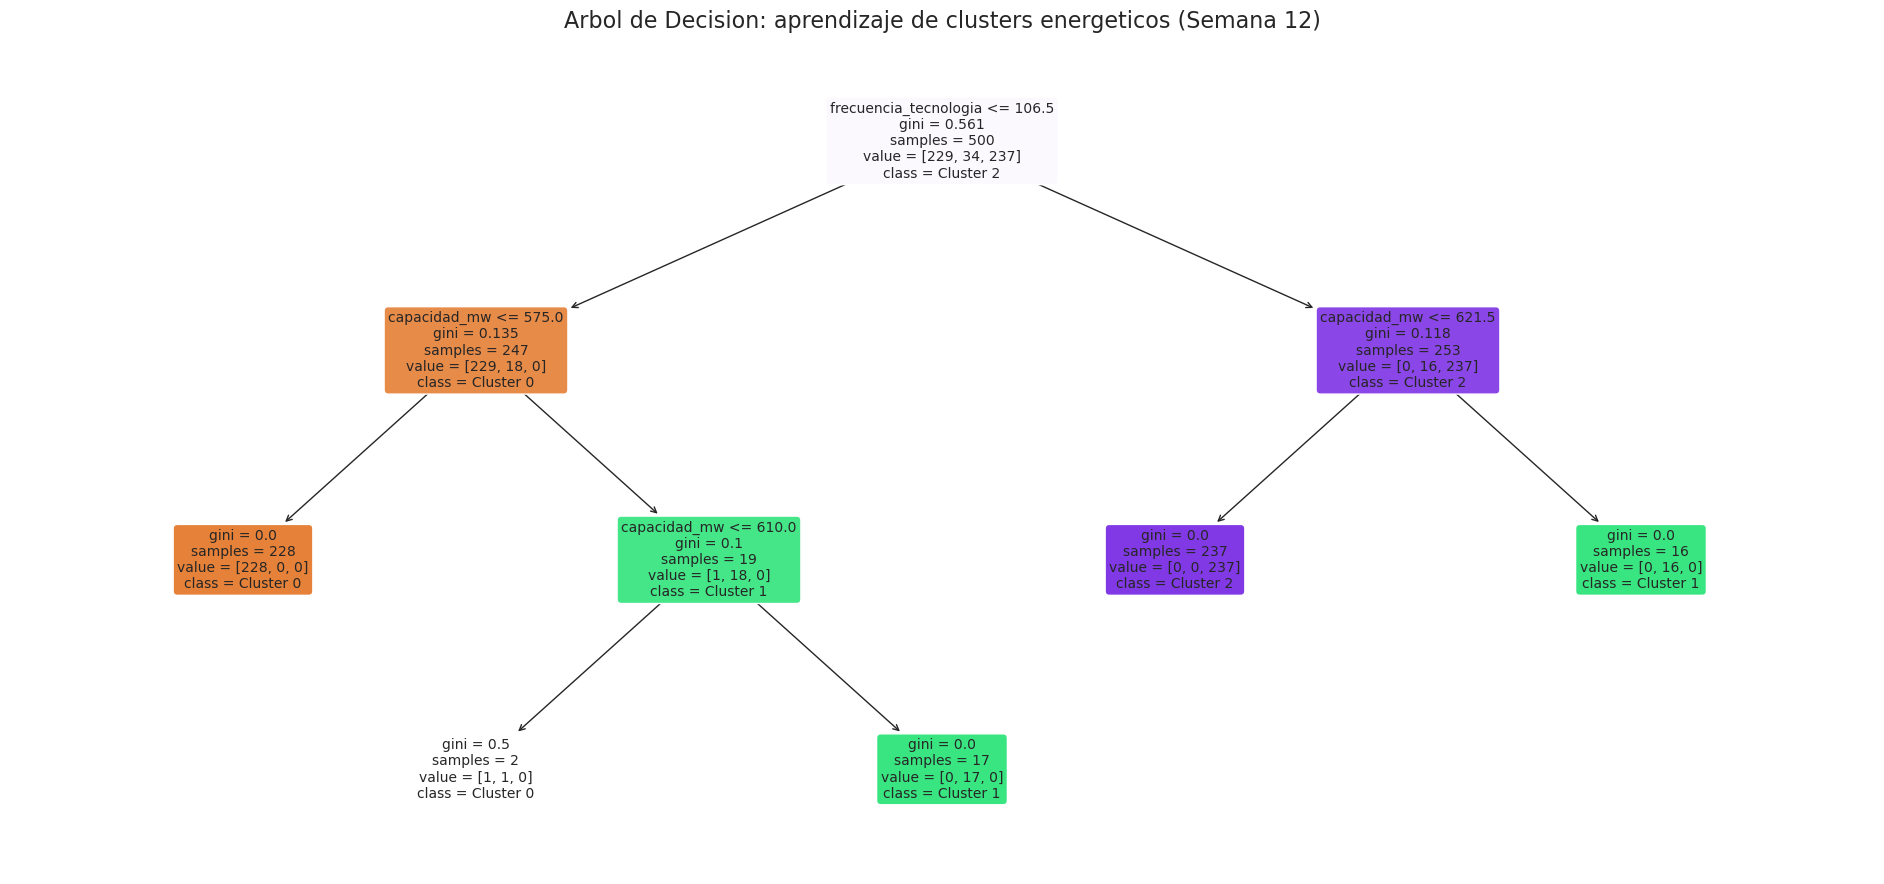

In [7]:
columnas_arbol = ["capacidad_mw", "frecuencia_tecnologia", "es_renovable"]
pdf_arbol = df_supervisado.select(*columnas_arbol, "label").toPandas()
X_muestra = pdf_arbol[columnas_arbol]
y_muestra = pdf_arbol["label"].astype(int)

sk_dt = SklearnDecisionTree(max_depth=3, random_state=42)
sk_dt.fit(X_muestra, y_muestra)
nombres_clases = [f"Cluster {c}" for c in sorted(y_muestra.unique())]

plt.figure(figsize=(19, 9), dpi=100)
plot_tree(
    sk_dt, feature_names=columnas_arbol, class_names=nombres_clases,
    filled=True, rounded=True, fontsize=10
)
plt.title("Arbol de Decision: aprendizaje de clusters energeticos (Semana 12)", fontsize=16)
plt.tight_layout()
plt.show()


## 5. Comparacion de clasificadores

Se evaluan Random Forest, SVM con estrategia OneVsRest y Regresion Logistica multinomial. Todos reciben `scaledFeatures` para conservar la misma preparacion usada en K-Means.


In [8]:
rf = RandomForestClassifier(featuresCol="scaledFeatures", labelCol="label", numTrees=20, seed=42)
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)
accuracy_rf = evaluator.evaluate(rf_predictions)

svm_binario = LinearSVC(featuresCol="scaledFeatures", labelCol="label", maxIter=20)
ovr_svm = OneVsRest(classifier=svm_binario, labelCol="label", featuresCol="scaledFeatures")
svm_model = ovr_svm.fit(train_data)
svm_predictions = svm_model.transform(test_data)
accuracy_svm = evaluator.evaluate(svm_predictions)

lr = LogisticRegression(featuresCol="scaledFeatures", labelCol="label", maxIter=20, family="multinomial")
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)
accuracy_lr = evaluator.evaluate(lr_predictions)


 RESULTADOS DE MODELOS SUPERVISADOS - SEMANA 12 
Random Forest: 100.00%
Regresion Logistica: 100.00%
Arbol de Decision: 99.21%
SVM OneVsRest: 97.62%


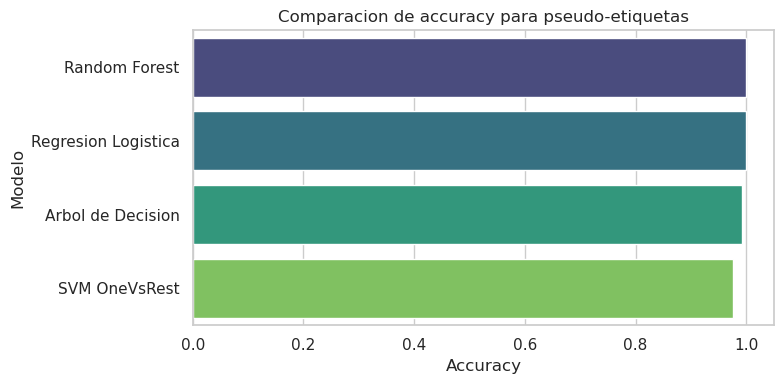

In [9]:
resultados_clasificacion = pd.DataFrame({
    "Modelo": ["Arbol de Decision", "Random Forest", "SVM OneVsRest", "Regresion Logistica"],
    "Accuracy": [accuracy_dt, accuracy_rf, accuracy_svm, accuracy_lr]
}).sort_values("Accuracy", ascending=False)

print("==================================================")
print(" RESULTADOS DE MODELOS SUPERVISADOS - SEMANA 12 ")
print("==================================================")
for _, fila in resultados_clasificacion.iterrows():
    print(f"{fila['Modelo']}: {fila['Accuracy'] * 100:.2f}%")
print("==================================================")

plt.figure(figsize=(8, 4))
sns.barplot(data=resultados_clasificacion, x="Accuracy", y="Modelo", hue="Modelo", palette="viridis", legend=False)
plt.xlim(0, 1.05)
plt.title("Comparacion de accuracy para pseudo-etiquetas")
plt.tight_layout()
plt.show()


## 6. Regresion: prediccion de capacidad instalada

Para evitar fuga de informacion, `capacidad_mw` no se incluye dentro de las caracteristicas de entrada: es la variable continua que queremos estimar. Se emplean la tecnologia, su frecuencia y si pertenece a energia renovable o fosil.


In [10]:
indexer = StringIndexer(inputCol="tecnologia", outputCol="tecnologia_index", handleInvalid="keep")
modelo_indexer = indexer.fit(df_clusters)
df_reg_base = modelo_indexer.transform(df_clusters)

assembler_regresion = VectorAssembler(
    inputCols=["frecuencia_tecnologia", "es_renovable", "tecnologia_index"],
    outputCol="features_regresion"
)
df_vector_reg = assembler_regresion.transform(df_reg_base)
scaler_reg = StandardScaler(inputCol="features_regresion", outputCol="scaledFeatures_regresion", withMean=True, withStd=True)
scaler_model_reg = scaler_reg.fit(df_vector_reg)
df_para_regresion = (scaler_model_reg.transform(df_vector_reg)
    .withColumn("label_capacidad", F.col("capacidad_mw").cast("double"))
    .drop("prediction")
)
train_reg, test_reg = df_para_regresion.randomSplit([0.7, 0.3], seed=42)
print("Entrenamiento regresion:", train_reg.count())
print("Prueba regresion:", test_reg.count())


Entrenamiento regresion: 374
Prueba regresion: 126


In [11]:
lr_regresion = LinearRegression(
    featuresCol="scaledFeatures_regresion", labelCol="label_capacidad", maxIter=20
)
lr_reg_model = lr_regresion.fit(train_reg)
predictions_regresion = lr_reg_model.transform(test_reg)

evaluator_r2 = RegressionEvaluator(labelCol="label_capacidad", predictionCol="prediction", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol="label_capacidad", predictionCol="prediction", metricName="rmse")
r2 = evaluator_r2.evaluate(predictions_regresion)
rmse = evaluator_rmse.evaluate(predictions_regresion)

print("=== COMPARATIVA: CAPACIDAD REAL VS CAPACIDAD PREDICHA ===")
predictions_regresion.select("item", "tecnologia", "label_capacidad", "prediction").show(10, truncate=False)
print(f"R2 de la regresion: {r2 * 100:.2f}%")
print(f"RMSE: {rmse:.2f} MW")
print(f"Interseccion: {lr_reg_model.intercept:.4f}")
print("Coeficientes [frecuencia_tecnologia, es_renovable, tecnologia_index]:", lr_reg_model.coefficients)


=== COMPARATIVA: CAPACIDAD REAL VS CAPACIDAD PREDICHA ===
+-----------------------+----------+---------------+------------------+
|item                   |tecnologia|label_capacidad|prediction        |
+-----------------------+----------+---------------+------------------+
|AGUA DEL TORO - Hydro  |Hydro     |130.0          |103.83718677609558|
|ALUMINE - Oil          |Oil       |1.904          |157.6820527867344 |
|ARROYITO - Hydro       |Hydro     |128.0          |103.83718677609558|
|ATUCHA I - Nuclear     |Nuclear   |370.0          |207.37938701505539|
|Ain Azel - Solar       |Solar     |20.0           |98.1945982855662  |
|Ain Djasser - Gas      |Gas       |520.0          |149.58992371482586|
|Ain Sekhouna - Solar   |Solar     |20.0           |98.1945982855662  |
|Albany Wind Farm - Wind|Wind      |21.6           |101.70848816999543|
|Amcor Gawler - Oil     |Oil       |4.0            |157.6820527867344 |
|Anglesea - Coal        |Coal      |165.0          |166.01481334010214|
+-----

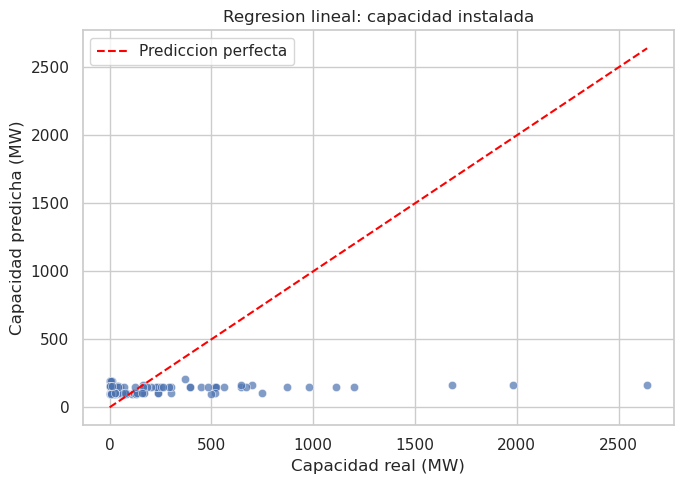

In [12]:
pdf_reg = predictions_regresion.select("label_capacidad", "prediction").toPandas()
plt.figure(figsize=(7, 5))
sns.scatterplot(data=pdf_reg, x="label_capacidad", y="prediction", alpha=0.7)
limite = max(pdf_reg["label_capacidad"].max(), pdf_reg["prediction"].max())
plt.plot([0, limite], [0, limite], "--", color="red", label="Prediccion perfecta")
plt.xlabel("Capacidad real (MW)")
plt.ylabel("Capacidad predicha (MW)")
plt.title("Regresion lineal: capacidad instalada")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Exportacion de resultados


In [13]:
salida = Path("salidas")
salida.mkdir(parents=True, exist_ok=True)

pdf_clasificacion = predictions_dt.select("item", "pais", "tecnologia", "capacidad_mw", "label", "prediction").toPandas()
pdf_clasificacion = pdf_clasificacion.rename(columns={"label": "cluster_kmeans", "prediction": "cluster_predicho_arbol"})
pdf_clasificacion.to_csv(salida / "clasificacion_pseudolabeling_thalia.csv", index=False)

pdf_regresion = predictions_regresion.select("item", "pais", "tecnologia", "capacidad_mw", "prediction").toPandas()
pdf_regresion = pdf_regresion.rename(columns={"prediction": "capacidad_predicha_mw"})
pdf_regresion.to_csv(salida / "regresion_capacidad_thalia.csv", index=False)
print("Archivos exportados en:", salida.resolve())


Archivos exportados en: /home/jovyan/work/semanas/Semana 12 Aprendizaje Semi Supervisado/salidas


## 8. Ticket de salida

**1. El problema es el algoritmo o los datos?**  
Los resultados muestran que los clasificadores reproducen muy bien la regla geometrica creada por K-Means: Arbol de Decision alcanzo 99.21%, Random Forest 100%, Regresion Logistica 100% y SVM OneVsRest 97.62% de accuracy. Esto no significa que se este prediciendo un fenomeno externo, sino que se esta aprendiendo la segmentacion construida previamente. En cambio, la regresion de capacidad obtuvo R2 = -0.45% y RMSE = 388.37 MW; el desafio esta principalmente en los datos, porque la capacidad de una central no depende solo de la tecnologia o de si es renovable.

**2. Como se solucionaria en el mundo real sin hacer trampa?**  
Se incorporarian variables que realmente explican la capacidad instalada: subtecnologia, ano de puesta en marcha, recurso disponible en la ubicacion, operador, inversion, capacidad de conexion a la red, factor de planta, generacion historica y emisiones. Con esas variables se podria comparar modelos y validar sus errores sobre centrales nuevas, sin utilizar la capacidad real dentro de las entradas.
